In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
#Importation des librairies
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import chi2_contingency, pearsonr, spearmanr, kendalltau, f_oneway, kruskal


In [55]:
#Importation du fichier web.xlsx
df_transactions = pd.read_csv("Transactions.csv", sep=';')
#Importation du fichier erp.xlsx
df_customers = pd.read_csv("customers.csv", sep=';')
#importation du fichier liaison.xlsx
df_products = pd.read_csv("products.csv", sep=';')

/tmp/ipython-input-3051139531.py:2: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_transactions = pd.read_csv("Transactions.csv", sep=';')


In [56]:
#EXPLORATION DES DONNEES

In [57]:
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 32.0+ MB


In [58]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB


In [59]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null   float64
 2   categ    3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB


In [60]:
# JOINTURE

In [61]:
df_1 = df_transactions.merge(df_customers, on="client_id", how="left")

df = df_1.merge(df_products, on="id_prod", how="left")


df = df.dropna()

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 687534 entries, 0 to 687533
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id_prod     687534 non-null  object 
 1   date        687534 non-null  object 
 2   session_id  687534 non-null  object 
 3   client_id   687534 non-null  object 
 4   sex         687534 non-null  object 
 5   birth       687534 non-null  float64
 6   price       687534 non-null  float64
 7   categ       687534 non-null  float64
dtypes: float64(3), object(5)
memory usage: 47.2+ MB


In [63]:
df.to_csv("jointure_export.csv", index=False)

In [64]:
# DEBUT DES ANALYSES

In [65]:
#Calcul CA
ca_total = df['price'].sum()
print(round(ca_total,2))

12027663.1


In [66]:
df['date'] = pd.to_datetime(df['date'])  # Verif dates pour moyenne mobile
df.set_index('date', inplace=True) # Pour pouvoir faire des resamples

In [67]:
CA_month = df['price'].resample('M').sum()
CA_day = df['price'].resample('D').sum()

/tmp/ipython-input-3538763561.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  CA_month = df['price'].resample('M').sum()


In [92]:
CA_rollingMonths = CA_month.rolling(window=3).mean()
CA_rollingDay = CA_day.rolling(window=30).mean()


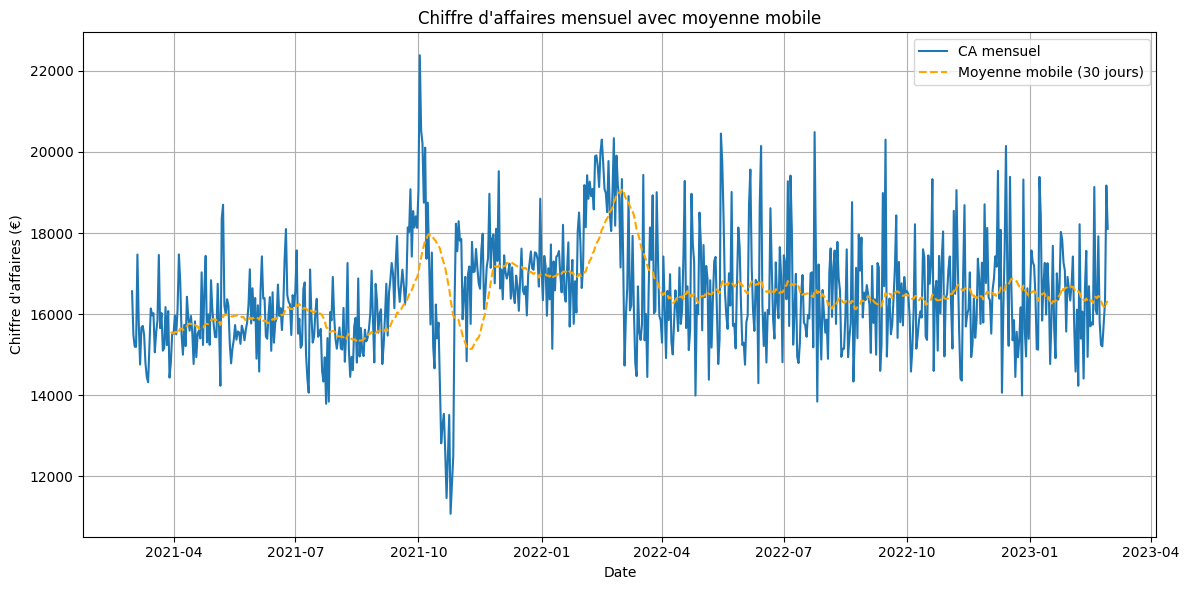

In [91]:
#GRAPH CA moyenne mobile

plt.figure(figsize=(12,6))
plt.plot(CA_day, label="CA mensuel")
plt.plot(CA_rollingDay, label="Moyenne mobile (30 jours)", linestyle='--', color='orange')
plt.title("Chiffre d'affaires mensuel avec moyenne mobile")
plt.xlabel("Date")
plt.ylabel("Chiffre d'affaires (€)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



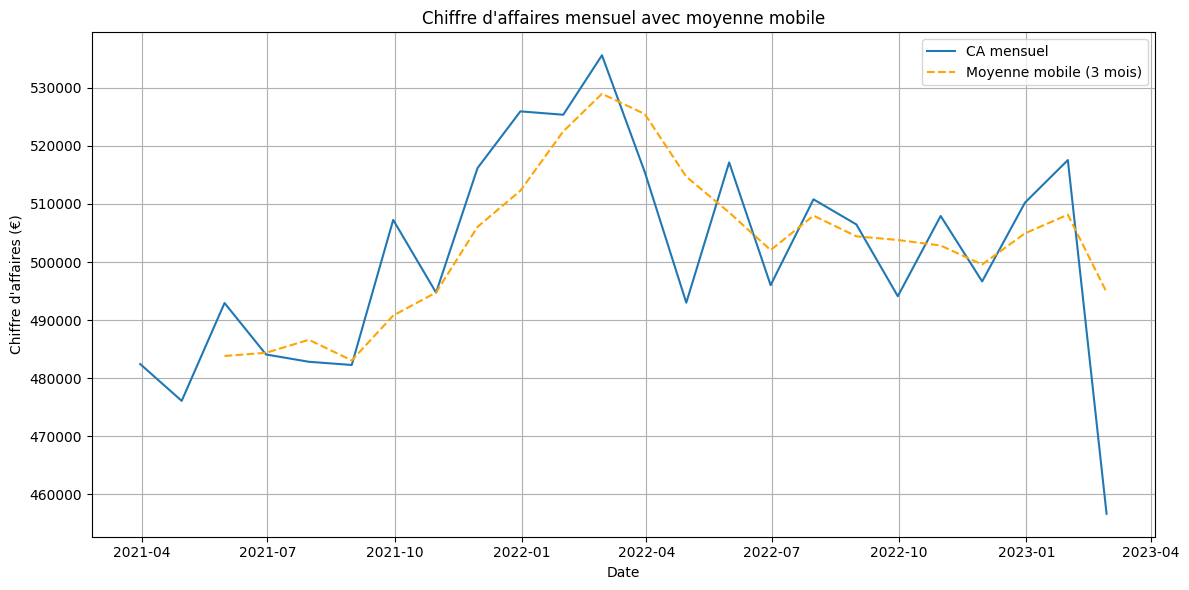

In [93]:
#GRAPH CA moyenne mobile

plt.figure(figsize=(12,6))
plt.plot(CA_month, label="CA mensuel")
plt.plot(CA_rollingMonths, label="Moyenne mobile (3 mois)", linestyle='--', color='orange')
plt.title("Chiffre d'affaires mensuel avec moyenne mobile")
plt.xlabel("Date")
plt.ylabel("Chiffre d'affaires (€)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#Faire par jour aussi / ou un seul mois pas 3 mois

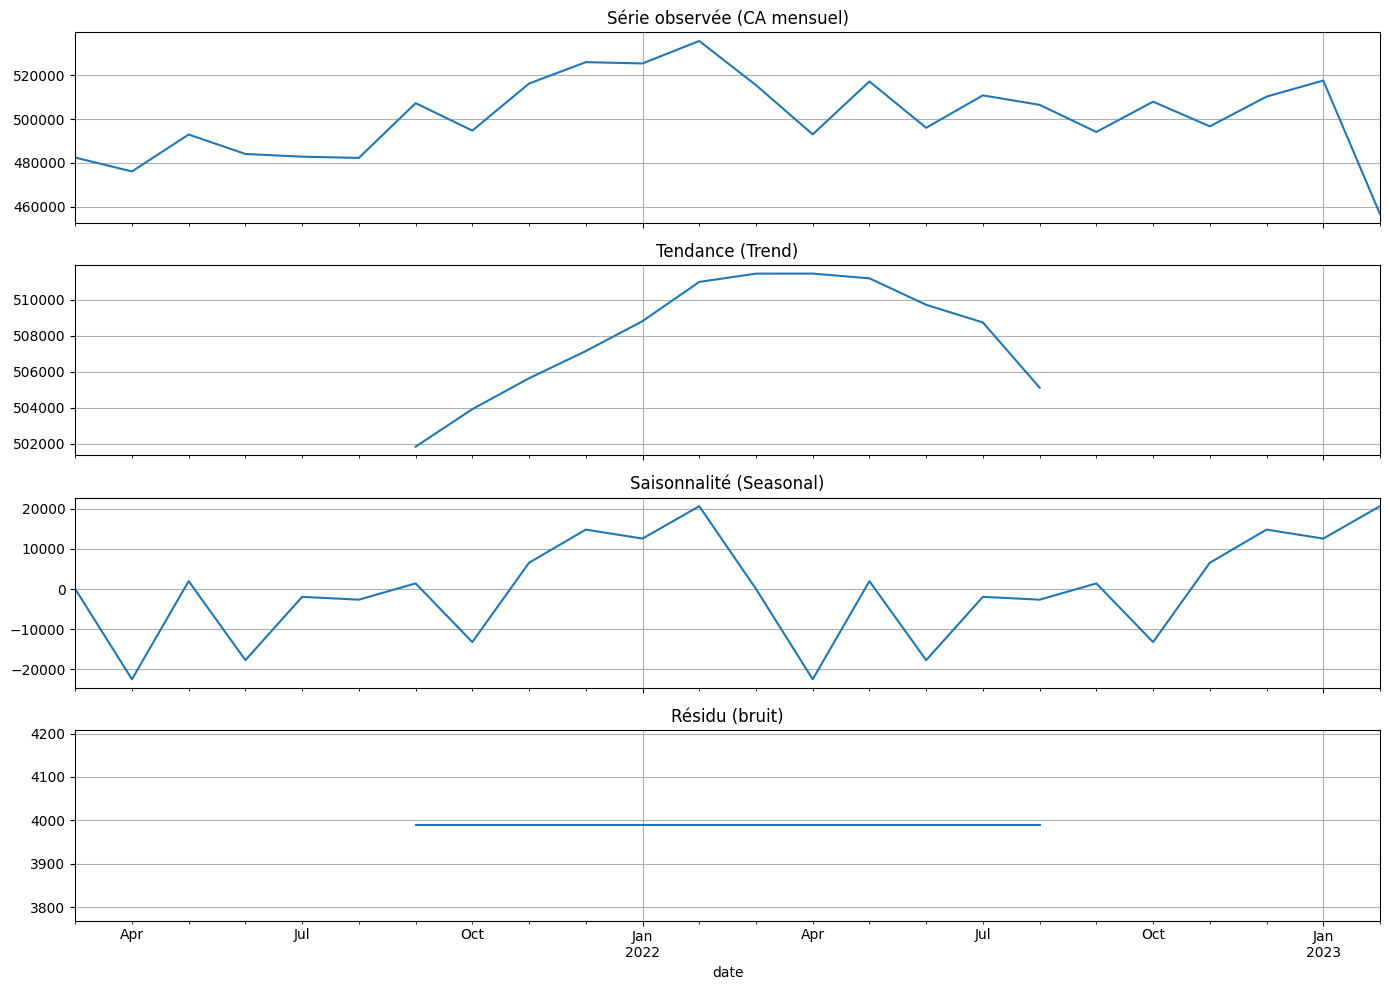

In [71]:
#tendance, saisonnalité et résidu (voir slack conseils)
decomposition = seasonal_decompose(CA_month, model='additive')  # ou model='multiplicative' selon le cas

#Affichage de la décomposition
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

decomposition.observed.plot(ax=ax1, title='Série observée (CA mensuel)')
decomposition.trend.plot(ax=ax2, title='Tendance (Trend)')
decomposition.seasonal.plot(ax=ax3, title='Saisonnalité (Seasonal)')
decomposition.resid.plot(ax=ax4, title='Résidu (bruit)')

for ax in (ax1, ax2, ax3, ax4):
    ax.grid(True)

plt.tight_layout()
plt.show()

In [72]:
# colonne date set to index donc il faut le remettre normalement pour pouvoir enchainer la suite des graphs
df = df.reset_index()

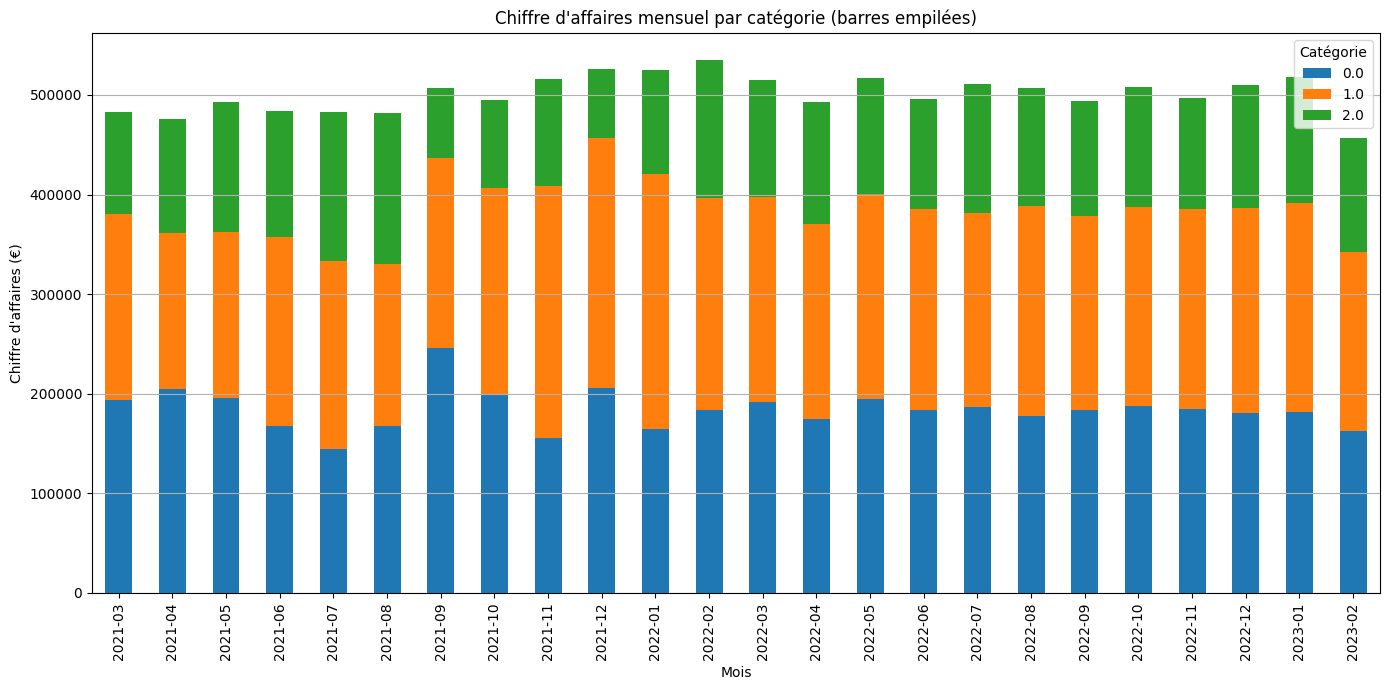

In [73]:
#GRAPH CA par categ

# Grouper par mois et par catégorie
df['mois'] = df['date'].dt.to_period('M')  # Période mensuelle
CA_mois_categ = df.groupby(['mois', 'categ'])['price'].sum().unstack(fill_value=0)



# Affichage du bar plot empilé
CA_mois_categ.plot(kind='bar', stacked=True, figsize=(14, 7))

plt.title("Chiffre d'affaires mensuel par catégorie (barres empilées)")
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires (€)")
plt.legend(title='Catégorie')
plt.tight_layout()
plt.grid(axis='y')
plt.show()

In [74]:
#Clients par mois
clients_par_mois = df.groupby('mois')['client_id'].nunique()

#nunique pour compter les clients différents pas si un achete 2 fois dans le mois et qu'il apparait deux fois

print(clients_par_mois)

mois
2021-03    5676
2021-04    5674
2021-05    5644
2021-06    5659
2021-07    5672
2021-08    5642
2021-09    5693
2021-10    6190
2021-11    5875
2021-12    5867
2022-01    5809
2022-02    5729
2022-03    5835
2022-04    5695
2022-05    5843
2022-06    5717
2022-07    5778
2022-08    5805
2022-09    5738
2022-10    5755
2022-11    5749
2022-12    5765
2023-01    5828
2023-02    5587
Freq: M, Name: client_id, dtype: int64


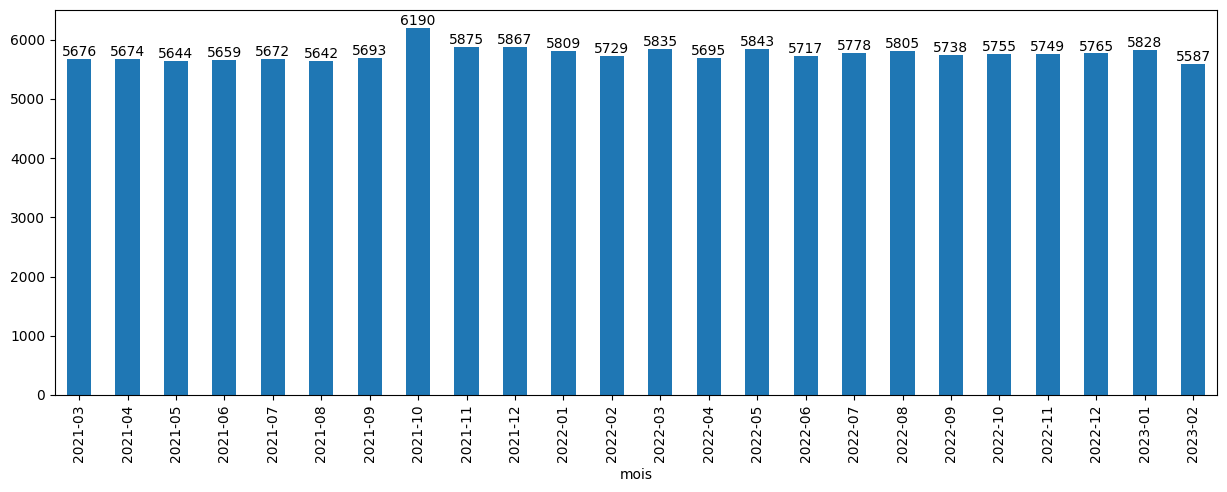

In [75]:
# GRAPH clients par mois
clients_par_mois.plot(kind='bar', figsize=(15,5))

# Ajout des valeurs
for i, val in enumerate(clients_par_mois):
    plt.text(i, val, str(val), ha='center', va='bottom')

plt.show()

In [76]:
#Calcul nombre de transac plus moyenne

#Transactions globale
transactions = len(df)
print("Au global sur toutes les données il y a :", transactions, "transactions")

# Nombre de transactions par année
transactions_par_an = df.groupby(df['date'].dt.year)['id_prod'].count()
moyenne_par_an = transactions_par_an.mean()
print("Moyenne de transactions par an :", round(moyenne_par_an))

# Nombre de transactions par mois (tous les mois de toutes les années confondues)
transactions_par_mois = df.groupby(df['mois'])['id_prod'].count()
moyenne_par_mois = transactions_par_mois.mean()
print("Moyenne de transactions par mois :", round(moyenne_par_mois))

Au global sur toutes les données il y a : 687534 transactions
Moyenne de transactions par an : 229178
Moyenne de transactions par mois : 28647


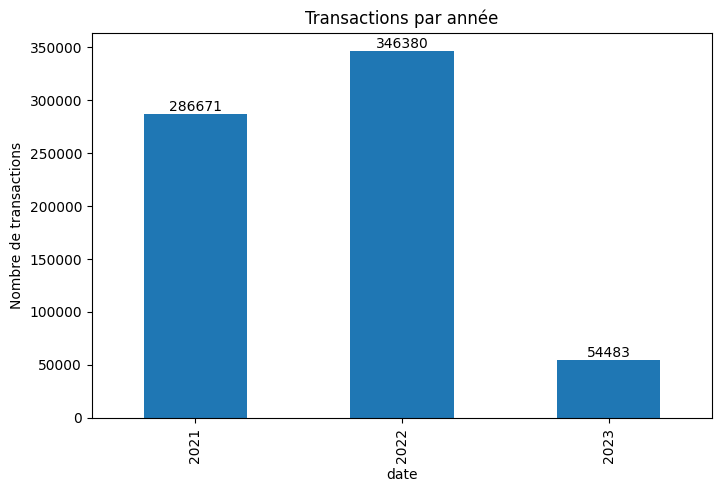

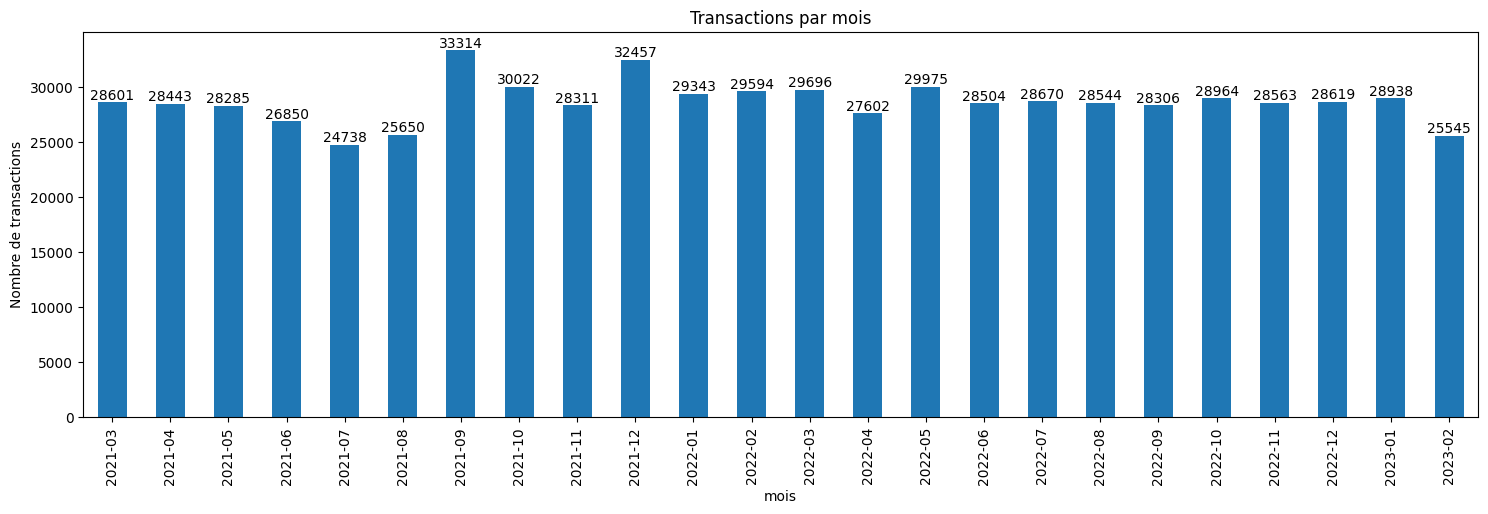

In [77]:
#GRAPH transac par an
transactions_par_an.plot(kind='bar', figsize=(8,5), title="Transactions par année")
plt.ylabel("Nombre de transactions")
for i, val in enumerate(transactions_par_an):
    plt.text(i, val, str(val), ha='center', va='bottom')
plt.show()


#GRAPH transac par mois

transactions_par_mois.plot(kind='bar', figsize=(18,5), title="Transactions par mois")
plt.ylabel("Nombre de transactions")
for i, val in enumerate(transactions_par_mois):
    plt.text(i, val, str(val), ha='center', va='bottom')
plt.show()

In [78]:
#GRAPH nombre de produit -> 1 produit par transaction? donc pareil que transac

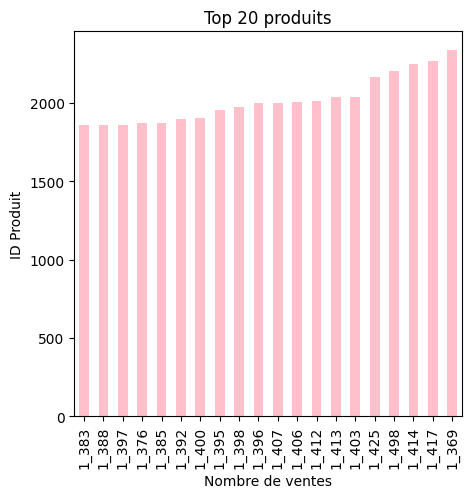

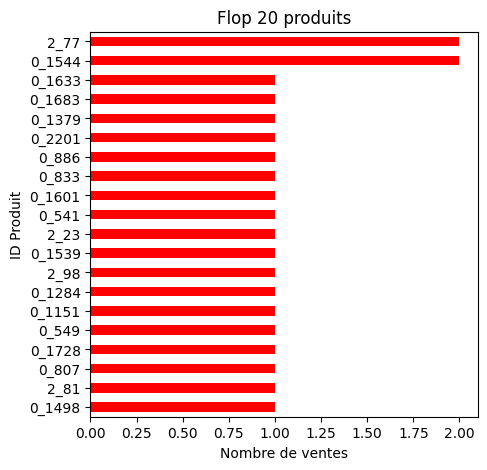

In [95]:
#Calcul des ventes par id_prod
ventes_par_produit = df['id_prod'].value_counts()

#Top 20 ventes
top20_ventes = ventes_par_produit.head(20)

#Flop 20 ventes
flop20_ventes = ventes_par_produit.tail(20)

# Graphique pour top 20
plt.figure(figsize=(5,5))
top20_ventes.sort_values().plot(kind='bar', color='pink')  # barres horizontales pour lisibilité
plt.title("Top 20 produits")
plt.xlabel("Nombre de ventes")
plt.ylabel("ID Produit")
plt.show()

# Graphique pour bottom 20
plt.figure(figsize=(5,5))
flop20_ventes.sort_values().plot(kind='barh', color='red')
plt.title("Flop 20 produits")
plt.xlabel("Nombre de ventes")
plt.ylabel("ID Produit")
plt.show()

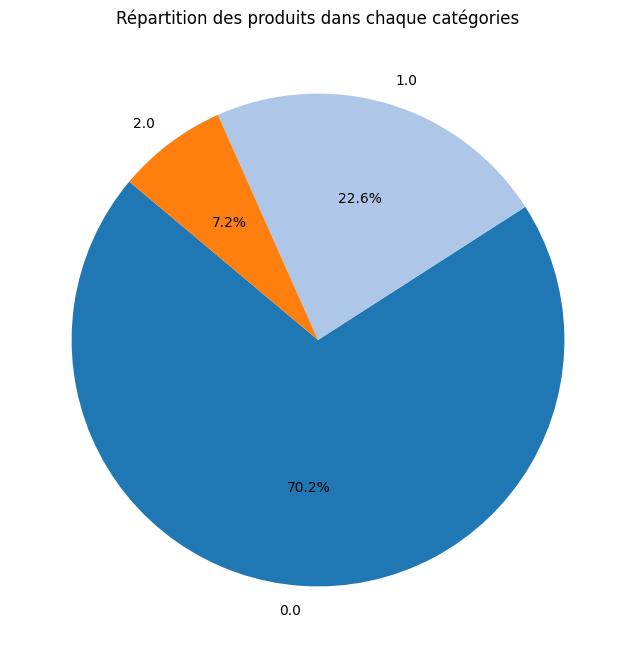

Prix moyen par catégorie :
categ
0.0    10.64
1.0    20.49
2.0    76.21
Name: price, dtype: float64


In [96]:
#Nombre de références uniques par catégorie
produits_par_categ = df.groupby('categ')['id_prod'].nunique()

#Prix moyen des produits par categ (Petit plus pour l'analyse)
prix_moyen_categorie = df.groupby('categ')['price'].mean()

#Camembert pour la répartition des références
plt.figure(figsize=(8,8))
plt.pie(produits_par_categ, labels=produits_par_categ.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab20.colors)
plt.title("Répartition des produits dans chaque catégories")
plt.show()

print("Prix moyen par catégorie :")
print(prix_moyen_categorie.round(2))

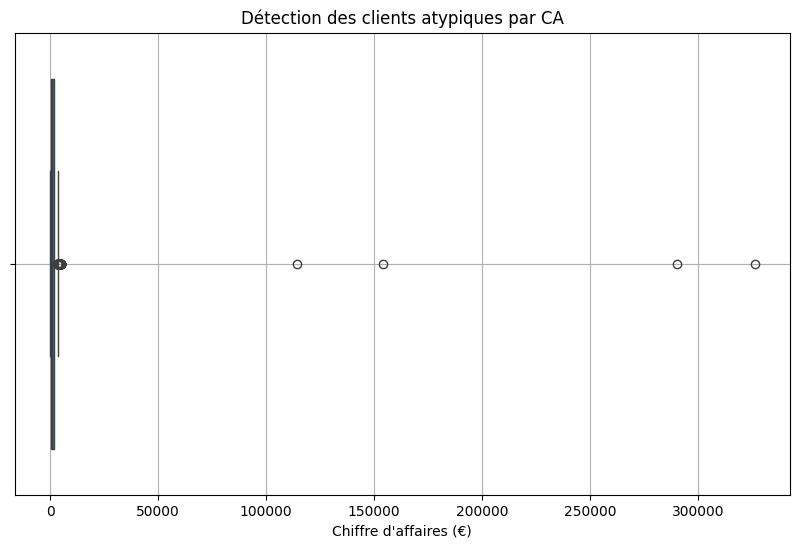

client_id
c_1609    326039.89
c_4958    290227.03
c_6714    153918.60
c_3454    114110.57
c_1570      5285.82
            ...    
c_4478        13.36
c_4648        11.20
c_8114         9.98
c_8140         8.30
c_8351         6.31
Name: price, Length: 8600, dtype: float64


In [81]:
#Recherche des clients BTOB Chiffre d'affaires par client

ca_client = df.groupby('client_id')['price'].sum()

# Création du boxplot
plt.figure(figsize=(10,6))
sns.boxplot(x=ca_client)

plt.title("Détection des clients atypiques par CA")
plt.xlabel("Chiffre d'affaires (€)")
plt.grid(True)
plt.show()

print(ca_client.sort_values(ascending=False))

#LES 4 clients outliers sont surement BtoB par leur CA


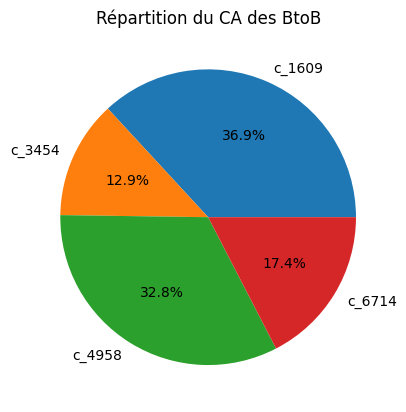

In [103]:
#Repartition du CA des clients top 4 (BTOB)
top4_clients = ["c_1609", "c_4958", "c_6714", "c_3454"]

df_with_top4 = df[df["client_id"].isin(top4_clients)]

#CA total
ca_top4 = df_with_top4.groupby("client_id")["price"].sum()

plt.pie(
    ca_top4,
    labels=ca_top4.index,
    autopct='%1.1f%%'
)
plt.title("Répartition du CA des BtoB")
plt.show()


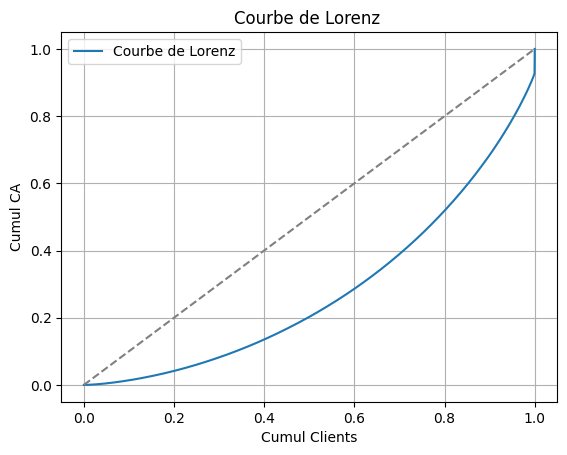

In [104]:
#CA calcul
ca_client = df.groupby('client_id')['price'].sum().sort_values()

#Calcul CA cumulés pour Lorenz (visu type pareto)
cumul_clients = np.linspace(0, 1, len(ca_client))
cumul_ca = np.cumsum(ca_client) / ca_client.sum()

# Tracé
plt.plot(cumul_clients, cumul_ca, label="Courbe de Lorenz")
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title("Courbe de Lorenz ")
plt.xlabel("Cumul Clients")
plt.ylabel("Cumul CA")
plt.legend()
plt.grid(True)
plt.show()